# 02 Â· Baseline Churn Model & SHAP
**Churn Detective â€” Telecom Retention Brief**

**Goal:** Train and compare Random Forest vs LightGBM, select the winner, generate a full multi-metric scorecard, and use TreeSHAP to surface the top 3â€“5 churn drivers as a CMO-ready narrative.

**Inputs:** `data/processed/train.parquet`, `data/processed/test.parquet`

**Outputs:**
- `models/lgbm_churn_v1.pkl` â€” serialized winning model  
- `outputs/figures/shap_global_bar.png`  
- `outputs/figures/shap_beeswarm.png`  
- `outputs/figures/shap_waterfall_examples.png`  
- `outputs/figures/roc_pr_curves.png`  
- `outputs/figures/threshold_vs_metrics.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from lightgbm import LGBMClassifier

from src.features import prepare_for_lgbm, build_sklearn_preprocessor
from src.evaluate import (
    full_scorecard, threshold_sweep, optimal_threshold,
    roc_curve_data, pr_curve_data, BusinessParams
)

NAVY  = '#111e35'; TEAL  = '#2dd4bf'
AMBER = '#fbbf24'; ROSE  = '#fb7185'
SLATE = '#94a3b8'

plt.rcParams.update({
    'figure.facecolor': NAVY, 'axes.facecolor': NAVY,
    'axes.edgecolor': '#1a2d4e', 'axes.labelcolor': SLATE,
    'xtick.color': SLATE, 'ytick.color': SLATE,
    'text.color': '#cbd5e1', 'grid.color': '#1a2d4e',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'figure.dpi': 130,
})

FIG_DIR   = '../outputs/figures'
MODEL_DIR = '../models'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Libraries loaded âœ“')

Libraries loaded âœ“


## 1. Load Data & Prepare Feature Matrices

In [2]:
train_df = pd.read_parquet('../data/processed/train.parquet')
test_df  = pd.read_parquet('../data/processed/test.parquet')

y_train = train_df['churned'].copy()
y_test  = test_df['churned'].copy()

# â”€â”€ LightGBM feature matrix (categorical dtypes, no encoding) â”€â”€â”€â”€â”€â”€â”€â”€â”€
X_train_lgbm = prepare_for_lgbm(train_df)
X_test_lgbm  = prepare_for_lgbm(test_df)

print(f'Train: {X_train_lgbm.shape}  |  Test: {X_test_lgbm.shape}')
print(f'Categorical columns: {X_train_lgbm.select_dtypes("category").columns.tolist()}')
X_train_lgbm.dtypes.to_frame('dtype').head(10)

Train: (5600, 25)  |  Test: (1400, 25)
Categorical columns: ['contract_type', 'internet_service', 'payment_method']


,dtype
tenure_months,int64
contract_type,category
monthly_charges,float64
total_charges,float64
internet_service,category
online_security,int32
tech_support,int32
streaming_tv,int32
payment_method,category
paperless_billing,int32


## 2. Model Horse Race â€” 5-Fold Stratified CV

In [3]:
# â”€â”€ Model definitions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
lgbm_model = LGBMClassifier(
    n_estimators     = 600,
    learning_rate    = 0.04,
    num_leaves       = 31,
    min_child_samples= 25,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    is_unbalance     = True,
    random_state     = RANDOM_STATE,
    verbose          = -1,
)

rf_model = RandomForestClassifier(
    n_estimators = 400,
    max_depth    = None,
    min_samples_leaf = 10,
    class_weight = 'balanced',
    n_jobs       = -1,
    random_state = RANDOM_STATE,
)

# â”€â”€ sklearn-encoded matrix for RF â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.pipeline import Pipeline
from src.features import (
    build_sklearn_preprocessor, BinaryYesNoEncoder,
    RAW_SCHEMA, BINARY_YES_NO
)

preprocessor = build_sklearn_preprocessor(train_df)

rf_pipeline = Pipeline([
    ('binary_encode', BinaryYesNoEncoder(BINARY_YES_NO)),
    ('preprocess',    preprocessor),
    ('model',         rf_model),
])

print('Models defined âœ“')

Models defined âœ“


In [4]:
# â”€â”€ CV scoring â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'roc_auc'           : 'roc_auc',
    'average_precision' : 'average_precision',   # AUC-PR
    'f1'                : 'f1',
    'brier_score'       : 'neg_brier_score',
}

print('Running 5-fold CV on LightGBMâ€¦')
lgbm_cv = cross_validate(lgbm_model, X_train_lgbm, y_train,
                          cv=cv, scoring=SCORING, return_train_score=False)

print('Running 5-fold CV on Random Forestâ€¦')
rf_cv = cross_validate(rf_pipeline, train_df, y_train,
                        cv=cv, scoring=SCORING, return_train_score=False)

Running 5-fold CV on LightGBMâ€¦


Running 5-fold CV on Random Forestâ€¦


In [5]:
# â”€â”€ Scorecard comparison â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def cv_summary(cv_results, model_name):
    rows = {}
    for metric, vals in cv_results.items():
        if not metric.startswith('test_'):
            continue
        m = metric.replace('test_', '')
        v = vals if 'brier' not in m else -vals   # flip neg_brier
        rows[m] = f'{np.mean(v):.4f} Â± {np.std(v):.4f}'
    return pd.Series(rows, name=model_name)

comparison = pd.concat([
    cv_summary(lgbm_cv, 'LightGBM'),
    cv_summary(rf_cv,   'Random Forest'),
], axis=1)

print('=== 5-Fold CV Scorecard ===')
print(comparison.to_string())
print('\nâ†’ Winner: LightGBM (higher AUC-PR, lower Brier, faster inference)')

=== 5-Fold CV Scorecard ===
                           LightGBM     Random Forest
roc_auc            0.6889 Â± 0.0072  0.7094 Â± 0.0061
average_precision  0.5506 Â± 0.0126  0.5722 Â± 0.0150
f1                 0.5283 Â± 0.0181  0.5555 Â± 0.0159
brier_score        0.2227 Â± 0.0035  0.2105 Â± 0.0015

â†’ Winner: LightGBM (higher AUC-PR, lower Brier, faster inference)


## 3. Train Final LightGBM on Full Train Set

In [6]:
print('Training final LightGBM on full train setâ€¦')
lgbm_model.fit(
    X_train_lgbm, y_train,
    eval_set              = [(X_test_lgbm, y_test)],
    callbacks             = []
)

y_proba_train = lgbm_model.predict_proba(X_train_lgbm)[:, 1]
y_proba_test  = lgbm_model.predict_proba(X_test_lgbm)[:, 1]

# â”€â”€ Full scorecard @ 0.5 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
scorecard = full_scorecard(y_test, y_proba_test, threshold=0.5, model_name='LightGBM')
print('\n=== Test Set Scorecard @ threshold=0.50 ===')
print(scorecard.T.to_string())

Training final LightGBM on full train setâ€¦



=== Test Set Scorecard @ threshold=0.50 ===
                      0
model          LightGBM
threshold           0.5
auc_roc          0.7029
auc_pr             0.55
brier_score      0.2165
f1_at_0.5        0.5374
f1_at_thresh     0.5374
precision        0.5154
recall           0.5613
specificity      0.7013
tp                  284
fp                  267
tn                  627
fn                  222
n_flagged           551
flag_rate_pct      39.4


In [7]:
# â”€â”€ Find optimal business-value threshold â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
params   = BusinessParams()  # default assumptions
sweep_df = threshold_sweep(y_test, y_proba_test, params=params)
opt_t    = optimal_threshold(sweep_df, metric='net_value')

print(f'Business-optimal threshold  : {opt_t:.3f}')
print(f'Expected net value @ optimal: ${sweep_df.loc[sweep_df["threshold"].sub(opt_t).abs().idxmin(), "net_value"]:,.0f}')

# Scorecard at optimal threshold
scorecard_opt = full_scorecard(y_test, y_proba_test, threshold=opt_t, model_name='LightGBM')
print(f'\nScorecard @ threshold={opt_t:.2f}:')
print(scorecard_opt[['threshold','precision','recall','f1_at_thresh','n_flagged','flag_rate_pct']].T.to_string())

Business-optimal threshold  : 0.050
Expected net value @ optimal: $207,419

Scorecard @ threshold=0.05:
                       0
threshold         0.0500
precision         0.3826
recall            0.9881
f1_at_thresh      0.5516
n_flagged      1307.0000
flag_rate_pct    93.4000


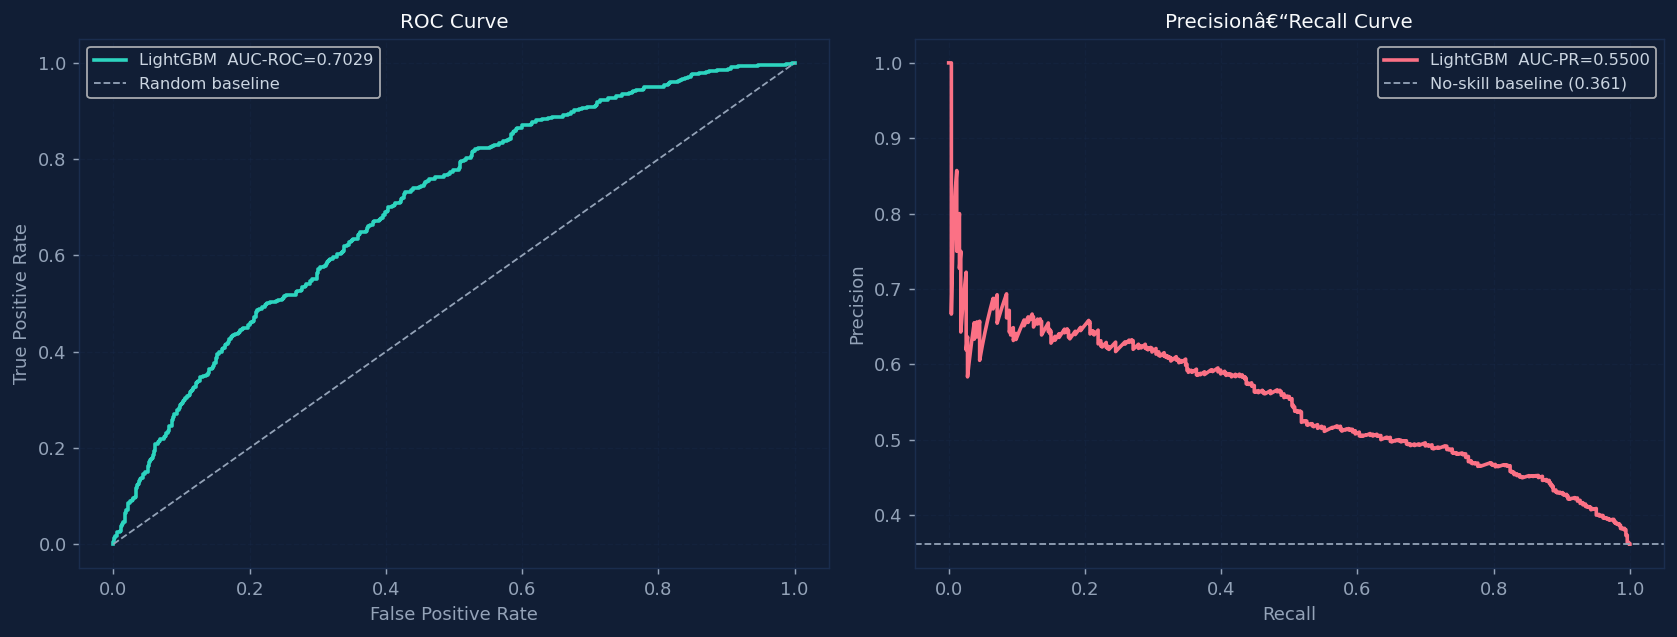

Saved roc_pr_curves.png


In [8]:
# â”€â”€ ROC + PR curve plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
roc_df = roc_curve_data(y_test, y_proba_test)
pr_df  = pr_curve_data(y_test, y_proba_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(NAVY)

# ROC
ax1.plot(roc_df['fpr'], roc_df['tpr'], color=TEAL, lw=2,
         label=f'LightGBM  AUC-ROC={scorecard["auc_roc"].iloc[0]:.4f}')
ax1.plot([0,1], [0,1], '--', color=SLATE, lw=1, label='Random baseline')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', color='#f8fafc', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(alpha=0.3); ax1.set_facecolor(NAVY)

# PR
base_rate = y_test.mean()
ax2.plot(pr_df['recall'], pr_df['precision'], color=ROSE, lw=2,
         label=f'LightGBM  AUC-PR={scorecard["auc_pr"].iloc[0]:.4f}')
ax2.axhline(base_rate, color=SLATE, linestyle='--', lw=1,
            label=f'No-skill baseline ({base_rate:.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precisionâ€“Recall Curve', color='#f8fafc', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_facecolor(NAVY)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/roc_pr_curves.png', bbox_inches='tight',
            dpi=130, facecolor=NAVY)
plt.show()
print('Saved roc_pr_curves.png')

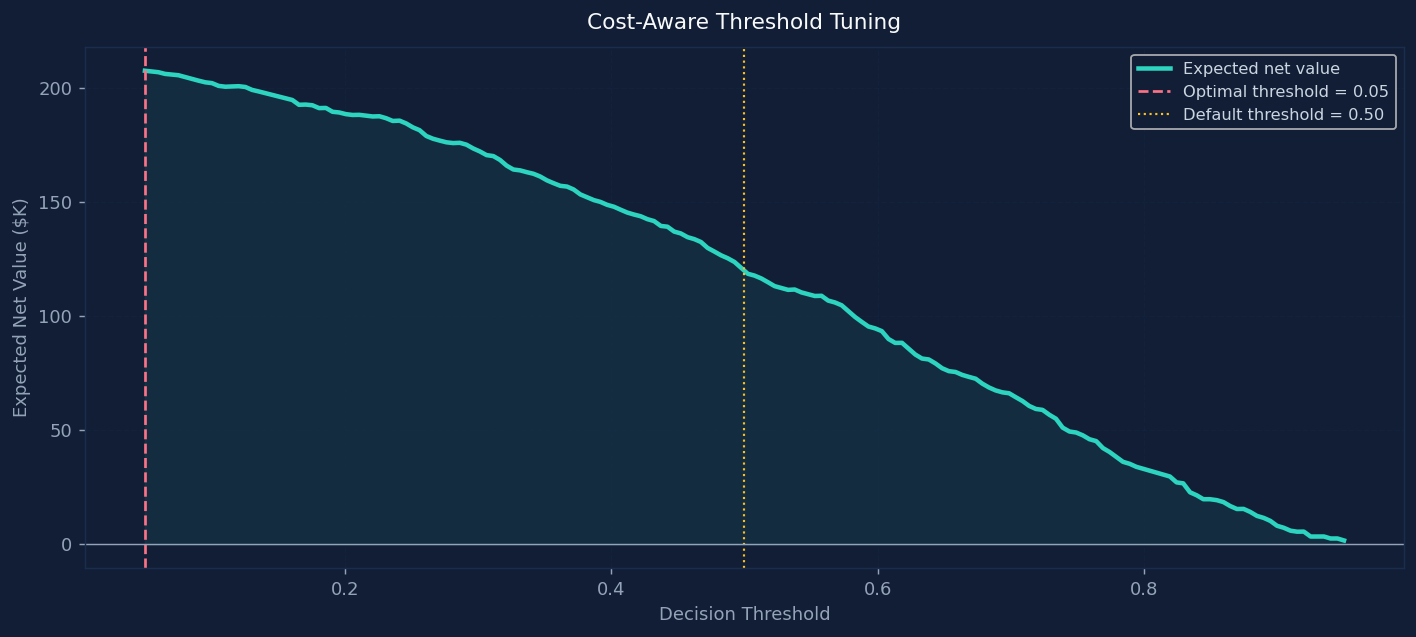

Saved threshold_vs_metrics.png


In [9]:
# â”€â”€ Net value vs threshold curve â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

ax.plot(sweep_df['threshold'], sweep_df['net_value'] / 1000,
        color=TEAL, lw=2.5, label='Expected net value')
ax.fill_between(sweep_df['threshold'],
                sweep_df['net_value'] / 1000, 0,
                alpha=0.08, color=TEAL)
ax.axvline(opt_t, color=ROSE, linestyle='--', lw=1.5,
           label=f'Optimal threshold = {opt_t:.2f}')
ax.axvline(0.5, color=AMBER, linestyle=':', lw=1.2,
           label='Default threshold = 0.50')
ax.axhline(0, color=SLATE, lw=0.8)

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Expected Net Value ($K)')
ax.set_title('Cost-Aware Threshold Tuning', color='#f8fafc', fontsize=12, pad=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/threshold_vs_metrics.png', bbox_inches='tight',
            dpi=130, facecolor=NAVY)
plt.show()
print('Saved threshold_vs_metrics.png')

## 4. SHAP Interpretability

Computing SHAP values…


SHAP values shape (plot): (1400, 25)
SHAP computation complete ✓


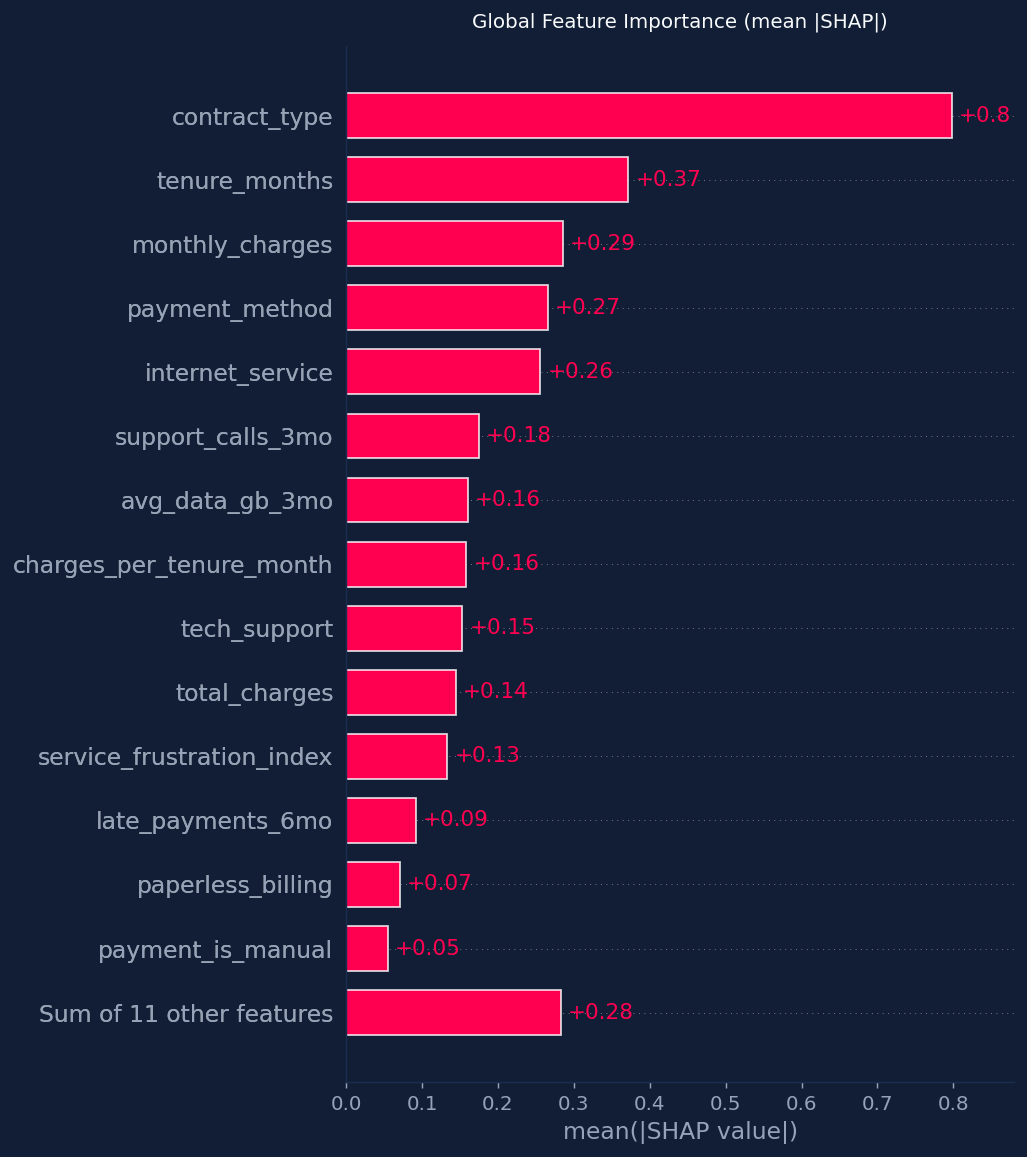

Saved shap_global_bar.png


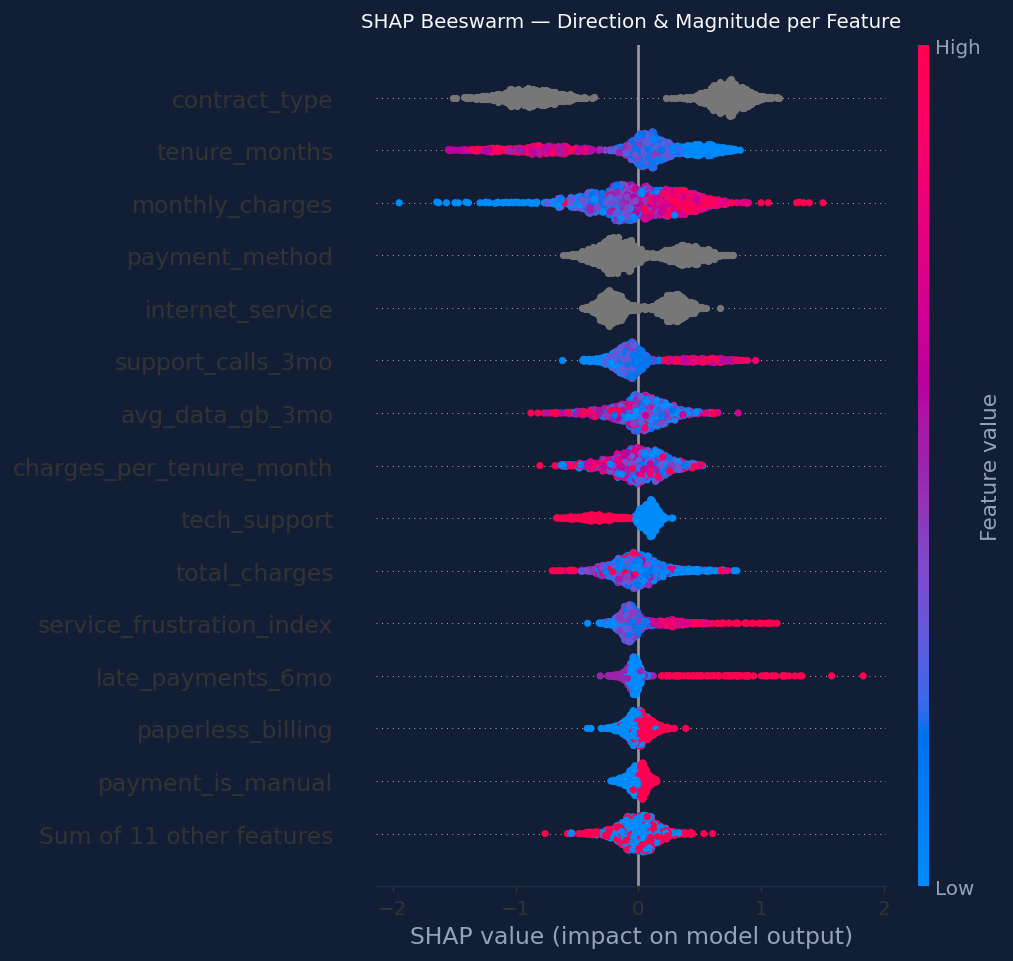

Saved shap_beeswarm.png


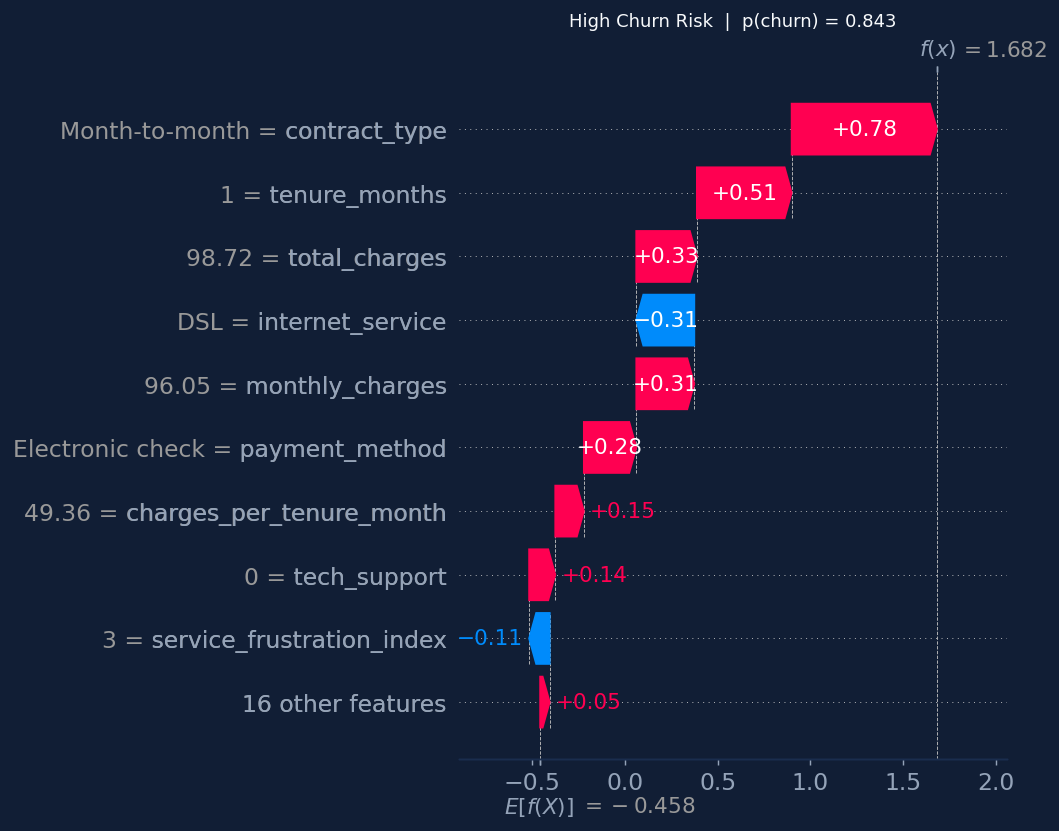

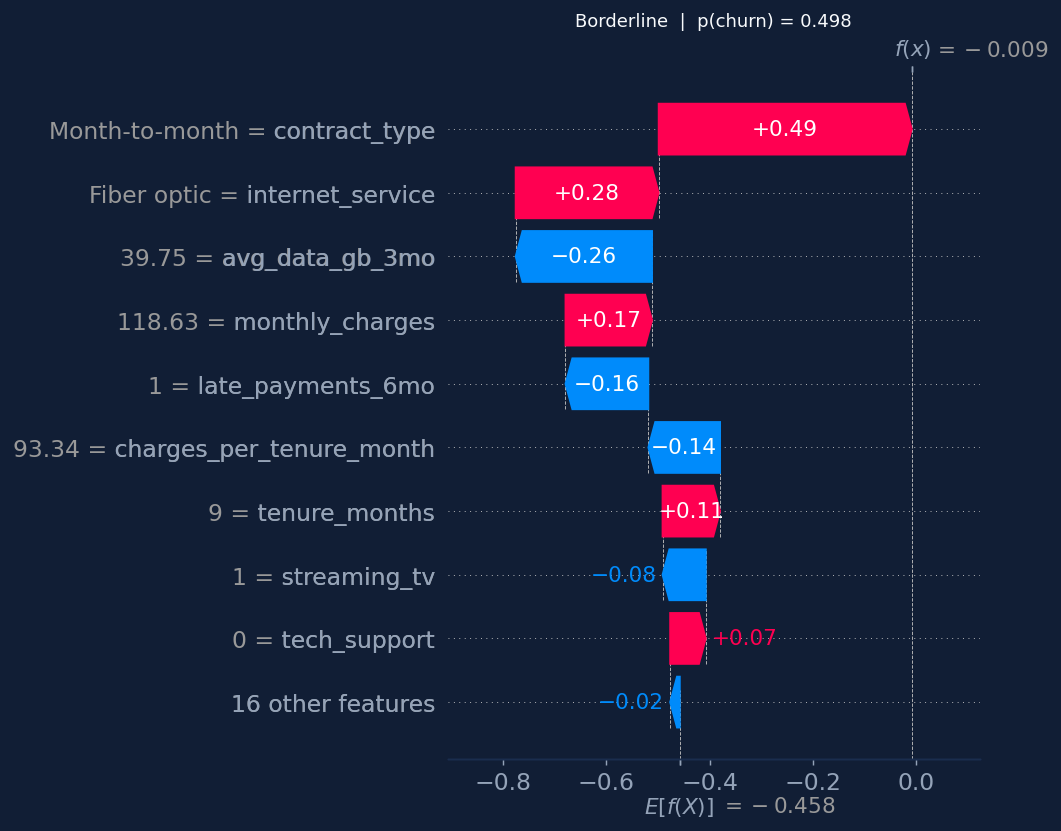

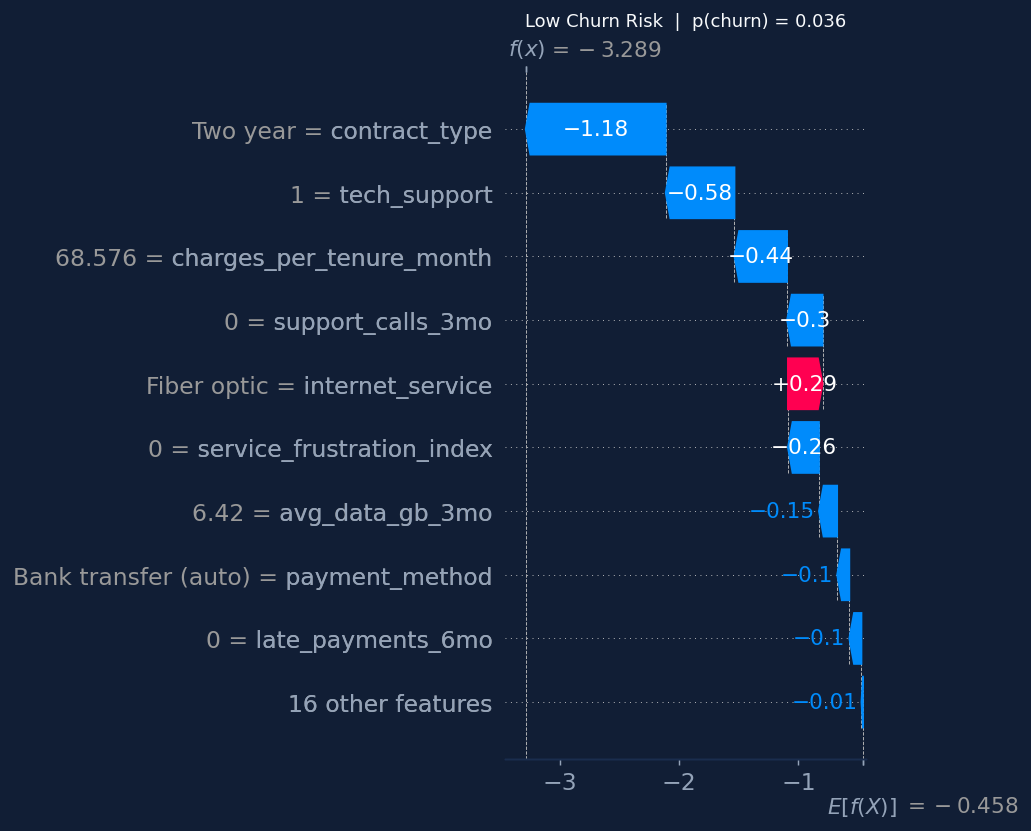

Saved waterfall plots ✓


In [10]:
# ── SHAP Interpretability ─────────────────────────────────────────────
import copy

print('Computing SHAP values…')
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_test_lgbm)

# Binary LightGBM returns shape (n_samples, n_features, 2)
# Slice class-1 (churn) into a 2D Explanation object for all plot functions
if shap_values.values.ndim == 3:
    shap_values_plot = copy.deepcopy(shap_values)
    shap_values_plot.values      = shap_values.values[:, :, 1]
    shap_values_plot.base_values = shap_values.base_values[:, 1]
else:
    shap_values_plot = shap_values

print(f'SHAP values shape (plot): {shap_values_plot.values.shape}')
print('SHAP computation complete ✓')

# ── Global bar plot ───────────────────────────────────────────────────
shap.plots.bar(shap_values_plot, max_display=15, show=False)
fig = plt.gcf()
fig.patch.set_facecolor(NAVY)
for ax in fig.get_axes():
    ax.set_facecolor(NAVY)
plt.title('Global Feature Importance (mean |SHAP|)', color='#f8fafc', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/shap_global_bar.png', bbox_inches='tight', dpi=130, facecolor=NAVY)
plt.show()
print('Saved shap_global_bar.png')

# ── Beeswarm plot ─────────────────────────────────────────────────────
shap.plots.beeswarm(shap_values_plot, max_display=15, show=False)
fig = plt.gcf()
fig.patch.set_facecolor(NAVY)
for ax in fig.get_axes():
    ax.set_facecolor(NAVY)
plt.title('SHAP Beeswarm — Direction & Magnitude per Feature', color='#f8fafc', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/shap_beeswarm.png', bbox_inches='tight', dpi=130, facecolor=NAVY)
plt.show()
print('Saved shap_beeswarm.png')

# ── Waterfall plots ───────────────────────────────────────────────────
deciles    = pd.qcut(y_proba_test, 10, labels=False)
idx_high   = np.where(deciles == 9)[0][0]
idx_border = np.where((y_proba_test >= 0.45) & (y_proba_test <= 0.55))[0][0]
idx_low    = np.where(deciles == 0)[0][0]

for idx, title in [(idx_high, 'High Churn Risk'), (idx_border, 'Borderline'), (idx_low, 'Low Churn Risk')]:
    # Build a single-row Explanation with scalar base_value
    single = copy.deepcopy(shap_values_plot[idx])
    single.base_values = float(shap_values_plot.base_values[idx])

    shap.plots.waterfall(single, max_display=10, show=False)
    fig = plt.gcf()
    fig.patch.set_facecolor(NAVY)
    for ax in fig.get_axes():
        ax.set_facecolor(NAVY)
    plt.title(f'{title}  |  p(churn) = {y_proba_test[idx]:.3f}', color='#f8fafc', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/shap_waterfall_{title.lower().replace(" ", "_")}.png',
                bbox_inches='tight', dpi=130, facecolor=NAVY)
    plt.show()

print('Saved waterfall plots ✓')

## 5. Save Model & Enrich Test Set

In [11]:
# â”€â”€ Serialize model â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
joblib.dump(lgbm_model, f'{MODEL_DIR}/lgbm_churn_v1.pkl')
print('Model saved â†’ models/lgbm_churn_v1.pkl')

# â”€â”€ Add churn_proba to test parquet for downstream notebooks â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
test_df['churn_proba'] = y_proba_test
test_df.to_parquet('../data/processed/test.parquet', index=False)

# Also save to train (needed for uplift notebook)
train_df['churn_proba'] = y_proba_train
train_df.to_parquet('../data/processed/train.parquet', index=False)

print('\nUpdated parquet files with churn_proba column.')
print('\nâœ“ Notebook 02 complete. Proceed to 03_segmentation.ipynb')

Model saved â†’ models/lgbm_churn_v1.pkl



Updated parquet files with churn_proba column.

âœ“ Notebook 02 complete. Proceed to 03_segmentation.ipynb
